# Stockout EDA

Exploratory analysis for top-15 SKU stockout prediction. The modeling target is daily binary stockout at store-SKU level: `stock_hour6_22_cnt > 0`.

In [1]:
# Colab bootstrap: clone or update the repo, then run from its root.
from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/vibhor-5/btp.git"
REPO_DIR = Path("/content/btp")
try:
    import google.colab  # type: ignore  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)
    os.chdir(REPO_DIR)
else:
    os.chdir(Path.cwd())

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "top15_train.parquet"
TEST_PATH = DATA_DIR / "top15_test.parquet"
print("Project root:", PROJECT_ROOT)
print("Train exists:", TRAIN_PATH.exists(), TRAIN_PATH)
print("Test exists:", TEST_PATH.exists(), TEST_PATH)

try:
    import pyarrow  # noqa: F401
except ImportError:
    !pip -q install pyarrow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

Project root: /content/btp
Train exists: True /content/btp/data/top15_train.parquet
Test exists: True /content/btp/data/top15_test.parquet


In [2]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

for name, df in [("train", train_df), ("test", test_df)]:
    df["dt"] = pd.to_datetime(df["dt"])
    df["stockout"] = (df["stock_hour6_22_cnt"] > 0).astype(int)
    print(f"\n{name}: shape={df.shape}")
    print("date range:", df["dt"].min(), "to", df["dt"].max(), "unique days:", df["dt"].nunique())
    print("stores:", df["store_id"].nunique(), "products:", df["product_id"].nunique(), "store-product groups:", df.groupby(["store_id", "product_id"]).ngroups)
    print("stockout rate:", df["stockout"].mean().round(4), "positive rows:", int(df["stockout"].sum()))

display(train_df.head())
display(train_df.dtypes.to_frame("dtype"))


train: shape=(175575, 20)
date range: 2024-03-28 00:00:00 to 2024-06-10 00:00:00 unique days: 75
stores: 868 products: 15 store-product groups: 2341
stockout rate: 0.5354 positive rows: 94000

test: shape=(35115, 20)
date range: 2024-06-11 00:00:00 to 2024-06-25 00:00:00 unique days: 15
stores: 868 products: 15 store-product groups: 2341
stockout rate: 0.4361 positive rows: 15315


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,stockout
0,0,0,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, ...",13,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...",0.882,0,1,1.6999,15.48,73.54,1.97,1
1,0,1,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.3, 0.0, 0.0, ...",16,"[1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.882,0,1,1.7005,15.47,73.53,1.97,1
2,0,2,2,29,78,82,4,2024-03-28,1.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, ...",0.882,0,1,1.7000,15.72,73.51,1.51,1
3,0,12,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.0, 0.0, 0.2, ...",13,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...",0.882,0,1,1.7000,15.48,73.54,1.97,1
4,0,18,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, ...",10,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...",0.814,0,1,1.7008,16.03,73.48,1.36,1


,dtype
city_id,int64
store_id,int64
management_group_id,int64
first_category_id,int64
second_category_id,int64
third_category_id,int64
product_id,int64
dt,datetime64[ns]
sale_amount,float64
hours_sale,object


In [3]:
combined = pd.concat([train_df.assign(split="train"), test_df.assign(split="test")], ignore_index=True)

missing = combined.isna().mean().sort_values(ascending=False).to_frame("missing_rate")
display(missing[missing["missing_rate"] > 0])

target_summary = combined.groupby("split").agg(
    rows=("stockout", "size"),
    stockout_rate=("stockout", "mean"),
    stockout_hours_mean=("stock_hour6_22_cnt", "mean"),
    stockout_hours_p95=("stock_hour6_22_cnt", lambda x: np.percentile(x, 95)),
)
display(target_summary)

,missing_rate


,rows,stockout_rate,stockout_hours_mean,stockout_hours_p95
split,,,,
test,35115,0.436138,3.071793,16.0
train,175575,0.535384,3.595962,14.0


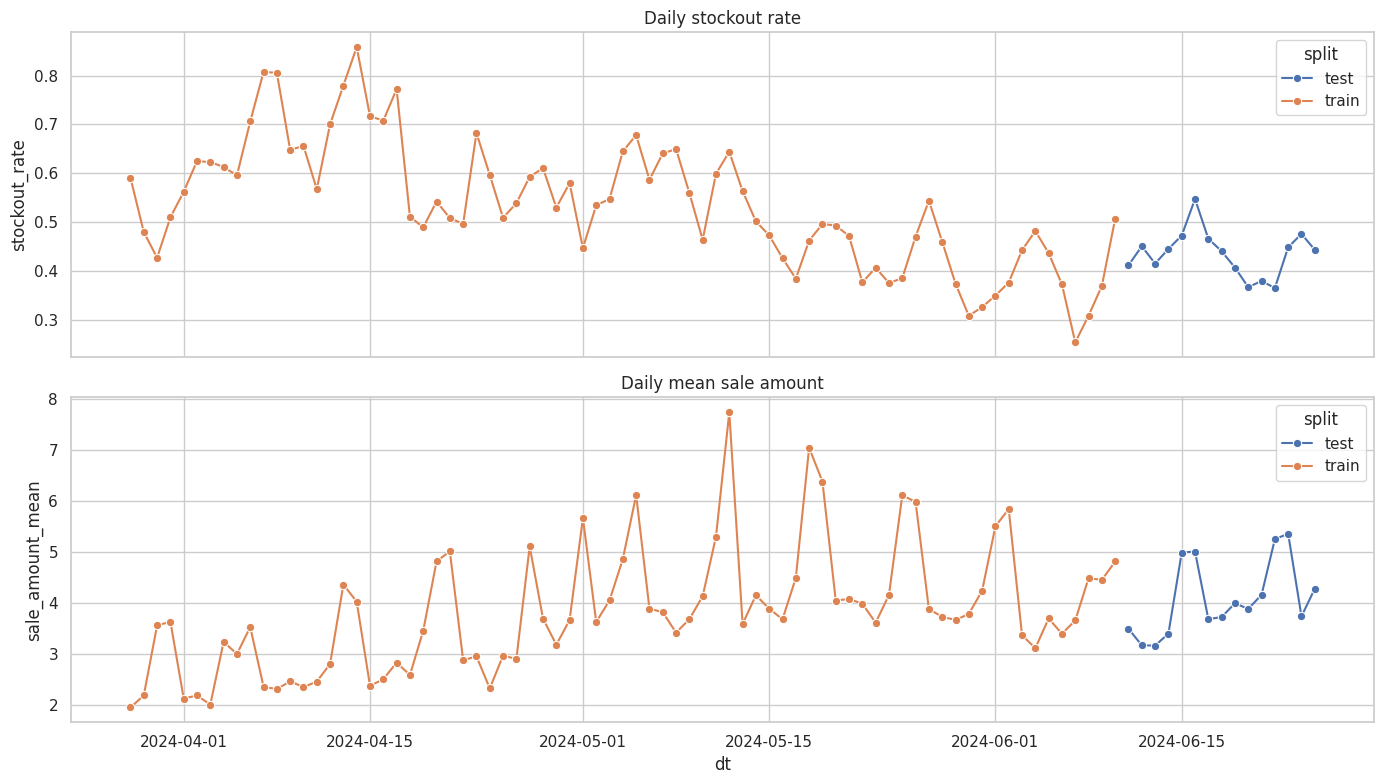

In [4]:
daily = combined.groupby(["split", "dt"], as_index=False).agg(
    stockout_rate=("stockout", "mean"),
    rows=("stockout", "size"),
    sale_amount_mean=("sale_amount", "mean"),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=daily, x="dt", y="stockout_rate", hue="split", marker="o", ax=axes[0])
axes[0].set_title("Daily stockout rate")
sns.lineplot(data=daily, x="dt", y="sale_amount_mean", hue="split", marker="o", ax=axes[1])
axes[1].set_title("Daily mean sale amount")
plt.tight_layout()

,product_id,rows,stockout_rate,sale_mean,sale_std,stock_hours_mean
11,589,4500,0.811778,10.792911,4.467456,4.418667
6,267,11790,0.781340,15.555140,9.354517,5.921628
7,300,37080,0.531823,4.166817,2.380842,3.473598
8,309,11340,0.507937,1.785610,1.616512,4.696384
5,191,32130,0.506909,2.057962,1.495630,3.818550
2,117,41310,0.489276,3.631880,1.912154,3.070927
0,4,70470,0.480176,2.600614,2.791802,3.017142
10,540,270,0.418519,8.172593,2.924678,2.551852
14,844,90,0.411111,2.971767,1.700823,4.100000
1,96,180,0.361111,5.808478,2.569519,2.766667


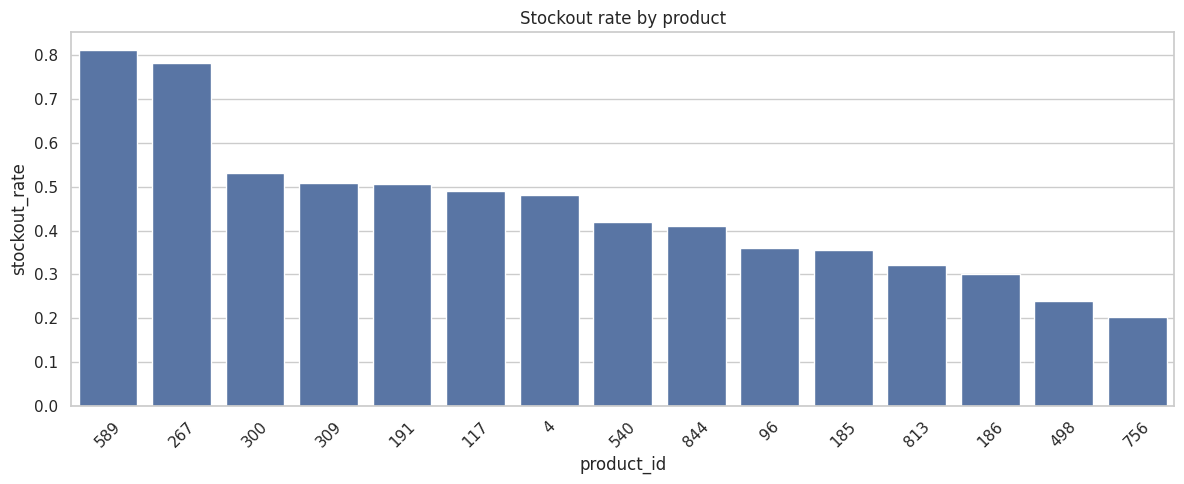

In [5]:
sku_summary = combined.groupby("product_id", as_index=False).agg(
    rows=("stockout", "size"),
    stockout_rate=("stockout", "mean"),
    sale_mean=("sale_amount", "mean"),
    sale_std=("sale_amount", "std"),
    stock_hours_mean=("stock_hour6_22_cnt", "mean"),
).sort_values("stockout_rate", ascending=False)
display(sku_summary)

plt.figure(figsize=(12, 5))
sns.barplot(data=sku_summary, x="product_id", y="stockout_rate", order=sku_summary["product_id"].astype(str))
plt.title("Stockout rate by product")
plt.xticks(rotation=45)
plt.tight_layout()

,store_id,rows,stockout_rate
138,141,90,0.822222
630,637,90,0.766667
830,859,180,0.766667
469,475,360,0.713889
33,33,270,0.703704
673,681,360,0.694444
133,136,270,0.692593
65,66,270,0.692593
659,667,270,0.685185
788,810,270,0.685185


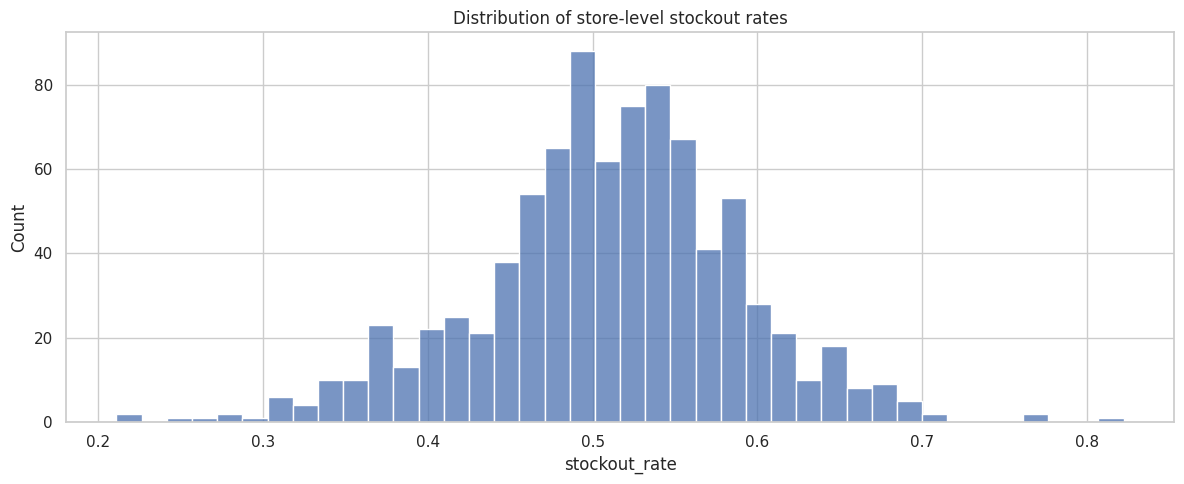

In [6]:
store_summary = combined.groupby("store_id", as_index=False).agg(
    rows=("stockout", "size"),
    stockout_rate=("stockout", "mean"),
).sort_values("stockout_rate", ascending=False)

display(store_summary.head(20))

plt.figure(figsize=(12, 5))
sns.histplot(store_summary["stockout_rate"], bins=40)
plt.title("Distribution of store-level stockout rates")
plt.tight_layout()

,count,mean,std,min,25%,50%,75%,max
sale_amount,210690.0,3.875703,4.496960,0.00,1.300,2.7000,4.600000,44.9000
discount,210690.0,0.846014,0.263755,0.00,0.821,0.9410,1.000000,1.0000
precpt,210690.0,4.070126,4.059198,0.00,1.497,2.4425,5.167925,34.5828
avg_temperature,210690.0,22.619294,3.612958,12.88,19.690,22.8400,25.800000,30.8800
avg_humidity,210690.0,75.189063,9.677465,27.35,71.960,76.8200,81.390000,92.6800
avg_wind_level,210690.0,1.764559,0.411517,0.97,1.450,1.6600,2.030000,3.8500
stock_hour6_22_cnt,210690.0,3.508600,4.616703,0.00,0.000,1.0000,6.000000,16.0000
stockout,210690.0,0.518843,0.499646,0.00,0.000,1.0000,1.000000,1.0000


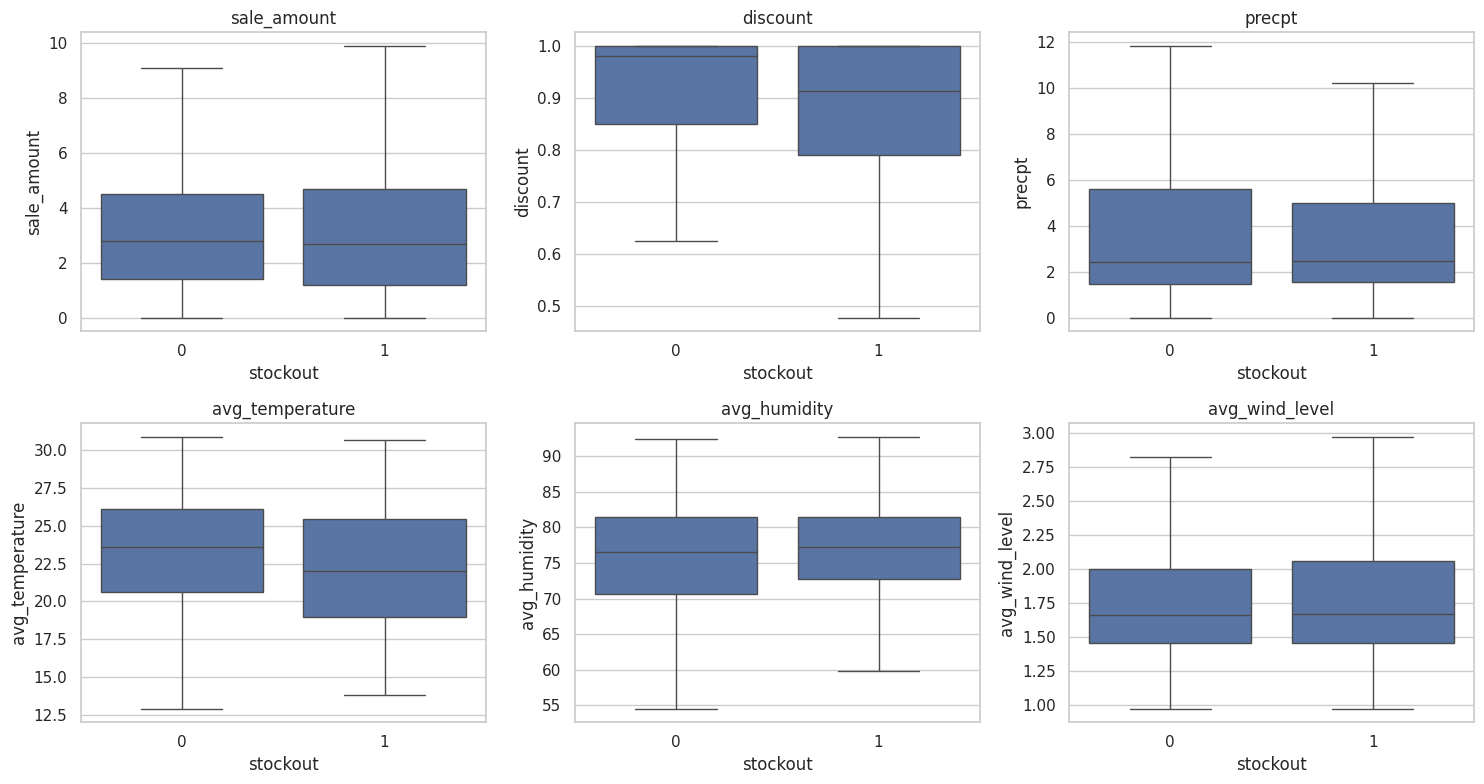

In [7]:
num_cols = ["sale_amount", "discount", "precpt", "avg_temperature", "avg_humidity", "avg_wind_level", "stock_hour6_22_cnt"]
available_num_cols = [c for c in num_cols if c in combined.columns]

display(combined[available_num_cols + ["stockout"]].describe().T)

sample = combined.sample(min(len(combined), 50000), random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), [c for c in available_num_cols if c != "stock_hour6_22_cnt"][:6]):
    sns.boxplot(data=sample, x="stockout", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()

In [8]:
group_sizes = combined.groupby(["store_id", "product_id"]).size()
display(group_sizes.describe().to_frame("rows_per_store_product"))

expected_days = combined["dt"].nunique()
continuity = combined.groupby(["store_id", "product_id"])["dt"].nunique().rename("unique_days").reset_index()
display(continuity["unique_days"].describe().to_frame())
print("Groups with full coverage:", int((continuity["unique_days"] == expected_days).sum()), "/", len(continuity))

,rows_per_store_product
count,2341.0
mean,90.0
std,0.0
min,90.0
25%,90.0
50%,90.0
75%,90.0
max,90.0


,unique_days
count,2341.0
mean,90.0
std,0.0
min,90.0
25%,90.0
50%,90.0
75%,90.0
max,90.0


Groups with full coverage: 2341 / 2341
